In [910]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [911]:
from data import data_loader
from features import tstat, volatility
from regime import state_labels

df = data_loader.get_data()
df = tstat.compute_tstat(df)
df = volatility.compute_volatility(df)
df = state_labels.label_volatility(df)
df = state_labels.label_regime(df)
df = state_labels.smooth_regime(df)

[*********************100%***********************]  1 of 1 completed
/Users/ak/Documents/GitHub/entropy-trading/regime/state_labels.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  .apply(lambda x: x[-1] if (x == x[-1]).sum() >= window else np.nan)


In [912]:
df.head()

Ticker,SPY,Log Return,T-Stat_200,Volatility,Vol State,Regime
Date,,,,,,
2008-01-03,103.728127,-0.000483,NaN,NaN,0,NaN
2008-01-04,101.186104,-0.024812,NaN,NaN,0,NaN
2008-01-07,101.100189,-0.000849,NaN,NaN,0,NaN
2008-01-08,99.467621,-0.016280,NaN,NaN,0,NaN
2008-01-09,100.513054,0.010455,NaN,NaN,0,0.0


In [913]:
df.tail()

Ticker,SPY,Log Return,T-Stat_200,Volatility,Vol State,Regime
Date,,,,,,
2024-12-24,594.320801,0.011054,1.432933,0.007806,1,1.0
2024-12-26,594.360352,0.000067,1.531649,0.007909,1,1.0
2024-12-27,588.103821,-0.010582,1.443918,0.007804,0,1.0
2024-12-30,581.392517,-0.011477,1.358180,0.007945,1,1.0
2024-12-31,579.277466,-0.003645,1.268187,0.008096,1,1.0


In [914]:
df[['Log Return', 'T-Stat_200', 'Volatility', 'Vol State', 'Regime']].tail(10)

Ticker,Log Return,T-Stat_200,Volatility,Vol State,Regime
Date,,,,,
2024-12-17,-0.004129,1.616926,0.006485,0,1.0
2024-12-18,-0.030257,1.587697,0.006517,0,1.0
2024-12-19,-0.000307,1.356805,0.007658,0,1.0
2024-12-20,0.011939,1.310546,0.007650,0,1.0
2024-12-23,0.005970,1.326528,0.007780,0,1.0
2024-12-24,0.011054,1.432933,0.007806,1,1.0
2024-12-26,0.000067,1.531649,0.007909,1,1.0
2024-12-27,-0.010582,1.443918,0.007804,0,1.0
2024-12-30,-0.011477,1.358180,0.007945,1,1.0


In [915]:
df[['Vol State', 'Regime']].dropna().dtypes

Ticker
Vol State      int64
Regime       float64
dtype: object

In [916]:
df['Log Return'].std()

0.01260154734959561

In [917]:
df['T-Stat_200'].describe()

count    4078.000000
mean        0.861157
std         0.915002
min        -1.691399
25%         0.212674
50%         0.896965
75%         1.620294
max         3.439017
Name: T-Stat_200, dtype: float64

In [918]:
df['Volatility'].describe()

count    4218.000000
mean        0.010684
std         0.006776
min         0.003136
25%         0.006923
50%         0.008619
75%         0.012334
max         0.047614
Name: Volatility, dtype: float64

In [919]:
df.isna().sum()

Ticker
SPY             0
Log Return      0
T-Stat_200    200
Volatility     60
Vol State       0
Regime          4
dtype: int64

In [975]:
df['Regime'].value_counts(normalize = True)

Regime
 0.0    0.703556
 1.0    0.294806
-1.0    0.001638
Name: proportion, dtype: float64

In [921]:
df['Vol State'].value_counts(normalize = True)

Vol State
0    0.767415
1    0.232585
Name: proportion, dtype: float64

<Axes: xlabel='Date', ylabel='T-Stat_200'>

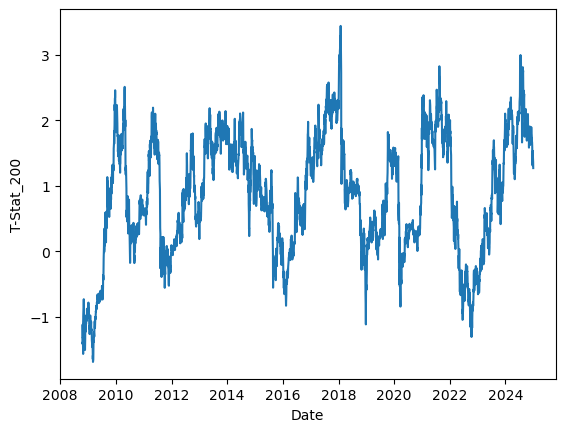

In [922]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lineplot(data = df['T-Stat_200'])

<Axes: xlabel='Date', ylabel='Volatility'>

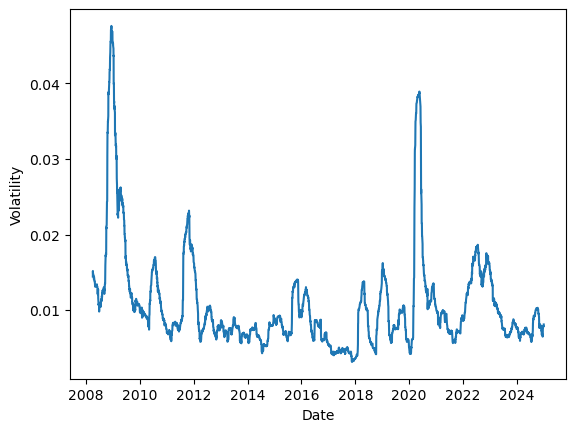

In [923]:
sns.lineplot(data = df['Volatility'])

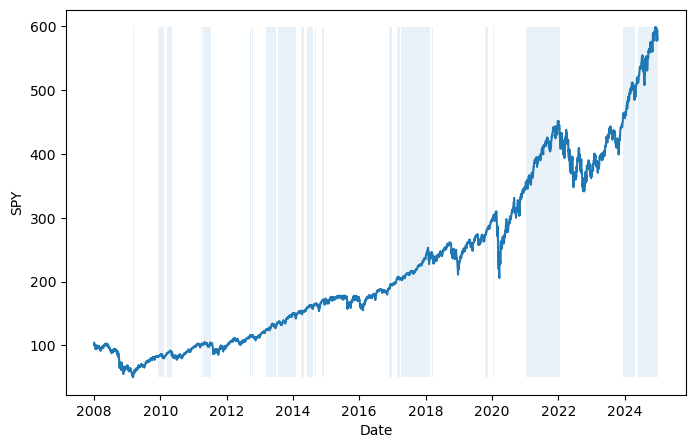

In [924]:
fig, ax = plt.subplots(figsize = (8, 5))
sns.lineplot(data = df['SPY'], ax = ax)
ax.fill_between(df.index, df['SPY'].min(), df['SPY'].max(), where = (df['Regime'] == 1), alpha = 0.1, label = 'Bull')
ax.fill_between(df.index, df['SPY'].min(), df['SPY'].max(), where = (df['Regime'] == -1), alpha = 0.15, label = 'Bear')

In [925]:
df['Forward Return'] = df['Log Return'].shift(-1)
df_new = df.dropna(subset = ['Forward Return'])

bull_mean = df_new.loc[df['Regime'] == 1, 'Forward Return'].mean()
neutral_mean = df_new.loc[df['Regime'] == 0, 'Forward Return'].mean()
bear_mean = df_new.loc[df['Regime'] == -1, 'Forward Return'].mean()

print(bull_mean)
print(neutral_mean)
print(bear_mean)

df_new.loc[df_new['Regime'] == -1, 'Forward Return'].describe()

0.0005089105497387257
0.00031617822469388965
0.022861095147461923


count    7.000000
mean     0.022861
std      0.021193
min     -0.003028
25%      0.007138
50%      0.022138
75%      0.034371
max      0.057901
Name: Forward Return, dtype: float64

In [926]:
df_new.groupby('Regime')['Forward Return'].std()

Regime
-1.0    0.021193
 0.0    0.014090
 1.0    0.007730
Name: Forward Return, dtype: float64

In [927]:
import numpy as np

bear_forward = df_new.loc[df_new['Regime'] == -1, 'Forward Return']

t = bear_forward.mean() / (bear_forward.std() / np.sqrt(len(bear_forward)))
print(t)

2.85403624793185


In [928]:
bull_forward = df_new.loc[df_new['Regime'] == 1, 'Forward Return']

t = bull_forward.mean() / (bull_forward.std() / np.sqrt(len(bull_forward)))
print(t)

2.3361568613740697


In [929]:
neutral_forward = df_new.loc[df_new['Regime'] == 0, 'Forward Return']

t = neutral_forward.mean() / (neutral_forward.std() / np.sqrt(len(neutral_forward)))
print(t)

1.2305496986073163


In [930]:
df['Forward Vol'] = df['Volatility'].shift(-1)
df_new = df.dropna(subset =['Forward Vol'])

df_new.groupby('Vol State')['Forward Vol'].mean()

Vol State
0    0.009509
1    0.014494
Name: Forward Vol, dtype: float64

In [931]:
from regime import matrix

df = matrix.initialize_state(df)

transition_matrix = matrix.build_stationary_matrix(df)
print(transition_matrix)

Next State    -1.0_0     0.0_0     0.0_1     1.0_0     1.0_1  nan_0
State                                                              
-1.0_0      0.857143  0.142857  0.000000  0.000000  0.000000   0.00
0.0_0       0.000466  0.978565  0.011650  0.009320  0.000000   0.00
0.0_1       0.000000  0.032520  0.965157  0.000000  0.002323   0.00
1.0_0       0.000000  0.014210  0.000000  0.976021  0.009769   0.00
1.0_1       0.000000  0.000000  0.037594  0.052632  0.909774   0.00
nan_0       0.000000  0.250000  0.000000  0.000000  0.000000   0.75


In [932]:
from regime import entropy

entropy_vector = entropy.find_entropy_vector(transition_matrix)
print(entropy_vector)

State
-1.0_0    0.410116
0.0_0     0.120223
0.0_1     0.159728
1.0_0     0.129351
1.0_1     0.364340
nan_0     0.562335
dtype: float64


<Axes: xlabel='Date', ylabel='Stationary Entropy'>

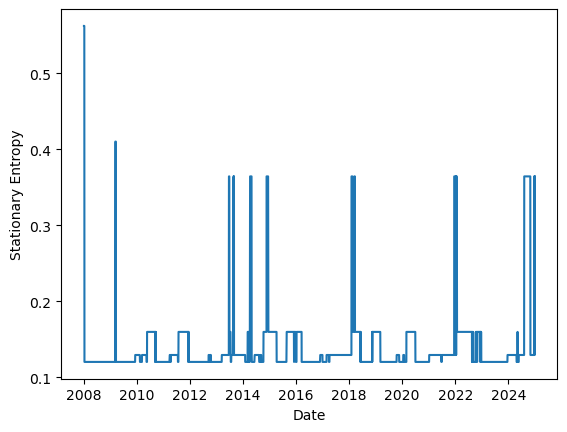

In [933]:
df = entropy.build_stationary_entropy(df, entropy_vector)

sns.lineplot(data = df['Stationary Entropy'])

<Axes: xlabel='Date', ylabel='Expanding Entropy'>

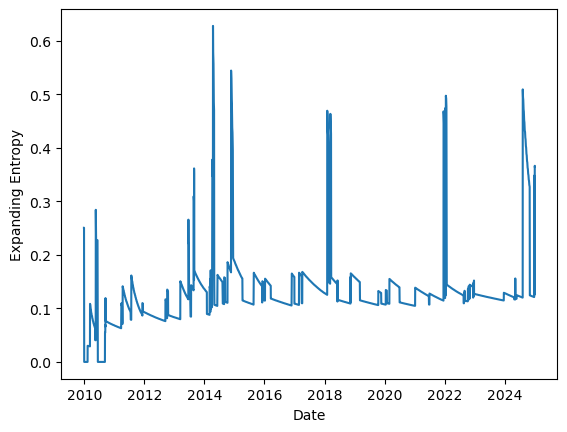

In [934]:
df = entropy.build_expanding_entropy(df)

sns.lineplot(data = df['Expanding Entropy'])

In [935]:
df['Expanding Entropy'].describe()

count    3778.000000
mean        0.129188
std         0.065742
min        -0.000000
25%         0.107980
50%         0.120804
75%         0.142249
max         0.627705
Name: Expanding Entropy, dtype: float64

In [936]:
df[[f'T-Stat_200', 'Log Return']].corr()

Ticker,T-Stat_200,Log Return
Ticker,,
T-Stat_200,1.000000,-0.024316
Log Return,-0.024316,1.000000


In [937]:
df[['Volatility', 'Log Return']].corr()

Ticker,Volatility,Log Return
Ticker,,
Volatility,1.000000,0.002394
Log Return,0.002394,1.000000


In [938]:
df[[f'T-Stat_200', 'Forward Return']].corr()

Ticker,T-Stat_200,Forward Return
Ticker,,
T-Stat_200,1.000000,-0.018997
Forward Return,-0.018997,1.000000


In [939]:
df[['Volatility', 'Forward Return']].corr()

Ticker,Volatility,Forward Return
Ticker,,
Volatility,1.000000,0.000393
Forward Return,0.000393,1.000000


In [940]:
from backtests import exposure

df = exposure.normalize_entropy(df)
df = exposure.normalize_tstat(df)
df = exposure.create_exposure(df)

In [941]:
df['Exposure'].describe()

count    4258.000000
mean        0.174410
std         0.375539
min        -0.837513
25%        -0.114735
50%         0.219252
75%         0.470603
max         0.921147
Name: Exposure, dtype: float64

In [942]:
(df['Exposure'].abs() > 0.8).mean()

0.021505376344086023

In [943]:
df['Trend'].describe()

count    4258.000000
mean        0.187196
std         0.401341
min        -0.874316
25%        -0.121947
50%         0.234731
75%         0.503253
max         0.952617
Name: Trend, dtype: float64

In [944]:
df['Confidence'].describe()

count    4278.000000
mean        0.936326
std         0.041540
min         0.649671
25%         0.922697
50%         0.935345
75%         0.950288
max         1.000000
Name: Confidence, dtype: float64

In [945]:
df['Exposure'].autocorr(lag = 1)

0.9394847499554734

In [946]:
df[['Exposure', 'Log Return']].corr()

Ticker,Exposure,Log Return
Ticker,,
Exposure,1.000000,-0.018038
Log Return,-0.018038,1.000000


In [947]:
df[['Exposure', 'Forward Return']].corr()

Ticker,Exposure,Forward Return
Ticker,,
Exposure,1.000000,-0.007828
Forward Return,-0.007828,1.000000


In [948]:
df.groupby('Vol State')['Exposure'].mean()

Vol State
0    0.217762
1    0.032243
Name: Exposure, dtype: float64

In [949]:
df.groupby('Regime')['Exposure'].mean()

Regime
-1.0   -0.546180
 0.0    0.121698
 1.0    0.303543
Name: Exposure, dtype: float64

In [950]:
df['Exposure Change'] = df['Exposure'].diff().abs()
df['Exposure Change'].mean()

0.09808252681152738

Text(0, 0.5, 'Exposure')

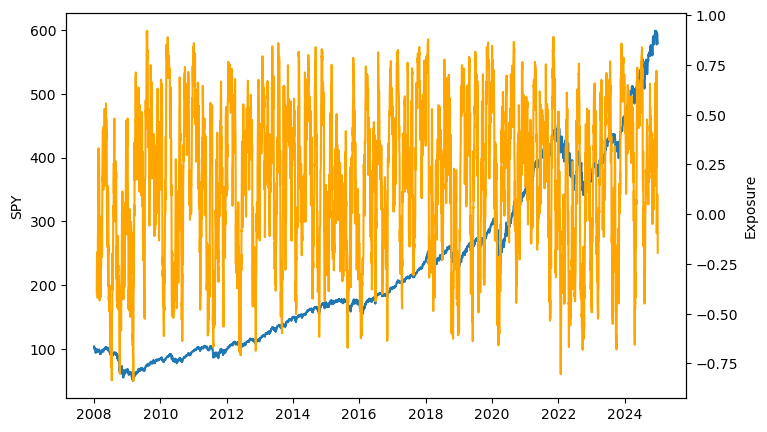

In [951]:
fig, ax1 = plt.subplots(figsize = (8, 5))

ax1.plot(df['SPY'], label = 'SPY')
ax1.set_ylabel('SPY')
ax2 = ax1.twinx()
ax2.plot(df['Exposure'], label = 'Exposure', color = 'Orange')
ax2.set_ylabel('Exposure')

Text(0, 0.5, 'Exposure')

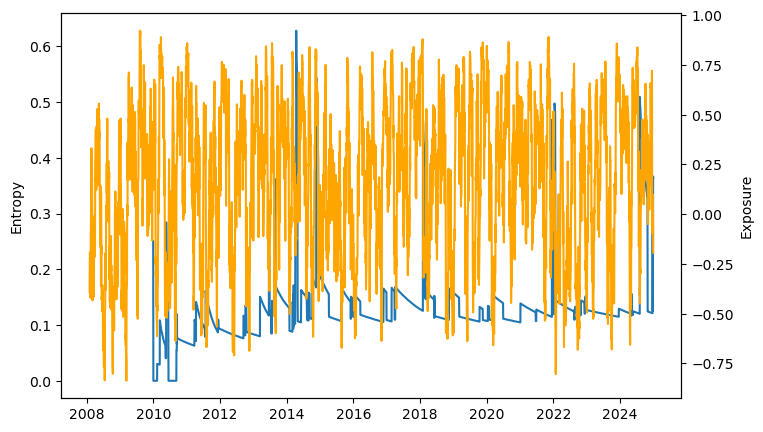

In [952]:
fig, ax1 = plt.subplots(figsize = (8, 5))

ax1.plot(df['Expanding Entropy'], label = 'Entropy')
ax1.set_ylabel('Entropy')
ax2 = ax1.twinx()
ax2.plot(df['Exposure'], label = 'Exposure', color = 'Orange')
ax2.set_ylabel('Exposure')

Text(0, 0.5, 'Exposure')

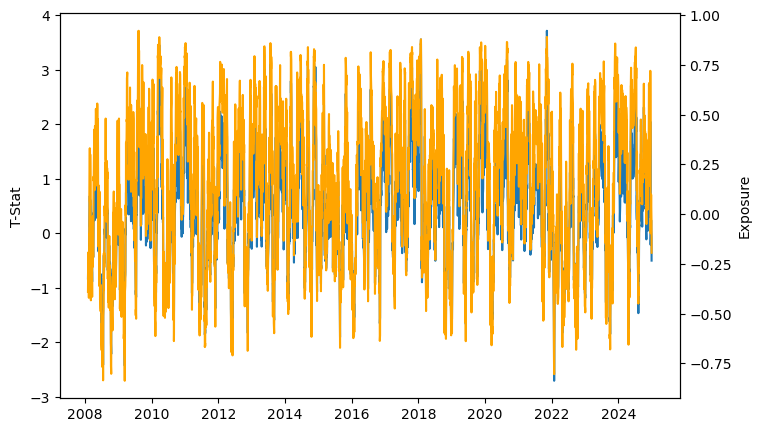

In [953]:
fig, ax1 = plt.subplots(figsize = (8, 5))

ax1.plot(df['T-Stat_20'], label = 'T-Stat-20')
ax1.set_ylabel('T-Stat')
ax2 = ax1.twinx()
ax2.plot(df['Exposure'], label = 'Exposure', color = 'Orange')
ax2.set_ylabel('Exposure')

<Axes: xlabel='Date'>

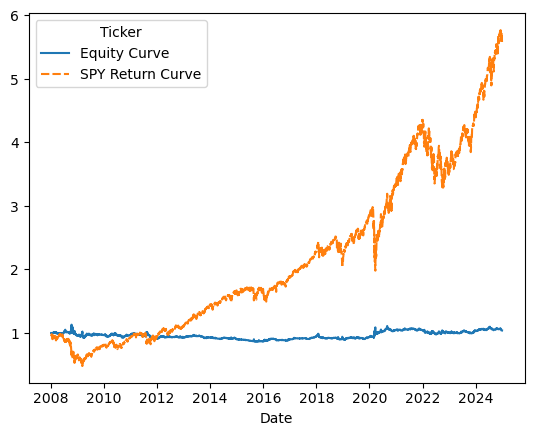

In [954]:
from backtests import backtest

df = backtest.run_backtest(df)
sns.lineplot(data = df[['Equity Curve', 'SPY Return Curve']])

<Axes: xlabel='Date', ylabel='Exposure'>

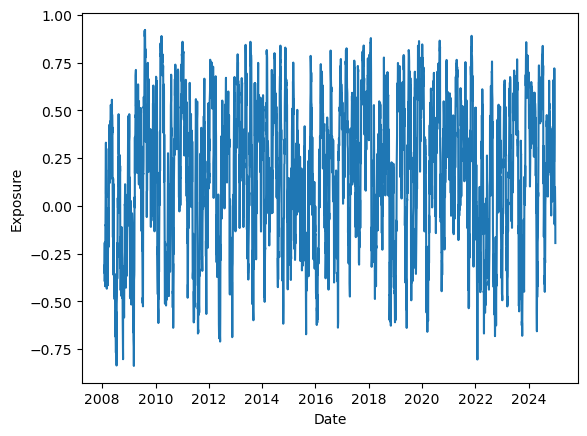

In [955]:
sns.lineplot(data = df['Exposure'])

In [956]:
(df['Exposure'] < 0).mean()

0.32538569424964936

In [957]:
df['Exposure'].corr(df['Pct Return'].shift(-1))

-0.013277139826318738

In [958]:
df['Expanding Entropy'].corr(df['Forward Vol'])

-0.002349072644769068

<Axes: xlabel='Date'>

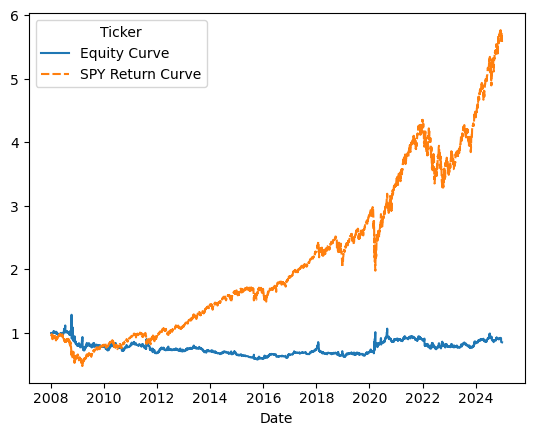

In [959]:
df['Exposure'] = df['T-Stat_20']
df['Exposure'].clip(0, 1)

df = backtest.run_backtest(df)
sns.lineplot(data = df[['Equity Curve', 'SPY Return Curve']])

In [960]:
(df['Exposure'] < 0).mean()

0.32538569424964936

<Axes: xlabel='Date'>

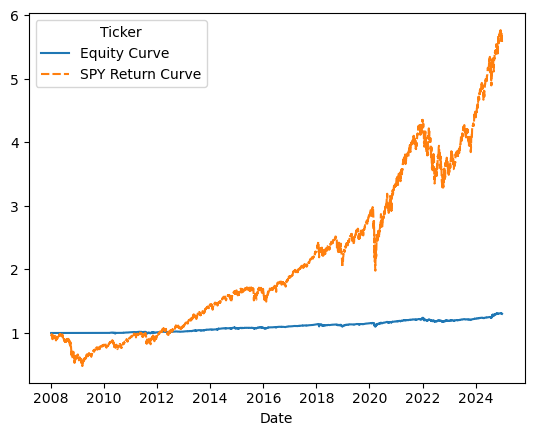

In [961]:
df['Exposure'] = df['Expanding Entropy']

df = backtest.run_backtest(df)
sns.lineplot(data = df[['Equity Curve', 'SPY Return Curve']])

In [962]:
import pandas as pd

df['Entropy Bins'] = pd.cut(df['Expanding Entropy'], bins = [0, 0.15, 0.4, 1], labels = ['Low', 'Mid', 'High'])

df.groupby('Entropy Bins')['Forward Vol'].mean().reset_index()

/var/folders/qd/xclxh05s0x9509nblm6z434w0000gp/T/ipykernel_50177/93630667.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Entropy Bins')['Forward Vol'].mean().reset_index()


,Entropy Bins,Forward Vol
0,Low,0.009470
1,Mid,0.009582
2,High,0.008992


<Axes: xlabel='Date'>

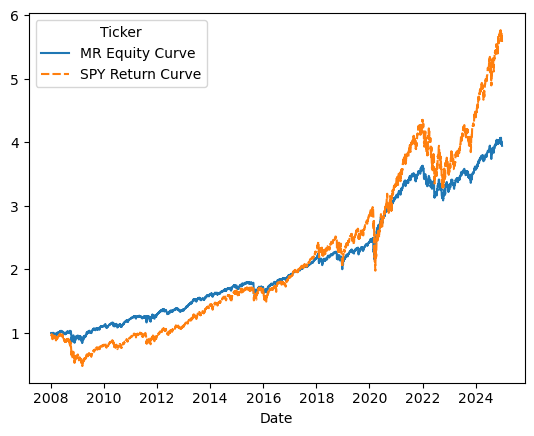

In [963]:
from backtests import mean_reversion
from features import zscore

df = zscore.calculate_zscore(df)
df = mean_reversion.generate_signal(df)
df = mean_reversion.mr_backtest(df)
sns.lineplot(data = df[['MR Equity Curve', 'SPY Return Curve']])

In [964]:
from evaluation import metrics

print(f"Mean-reversion-only Sharpe: {metrics.calculate_sharpe(df['MR Return'])}")
print(f"Mean-reversion-only max drawdown: {metrics.calculate_max_drawdown(df['MR Return'])}")

Mean-reversion-only Sharpe: 0.7752757540518905
Mean-reversion-only max drawdown: -0.18263358606593935


<Axes: xlabel='Date'>

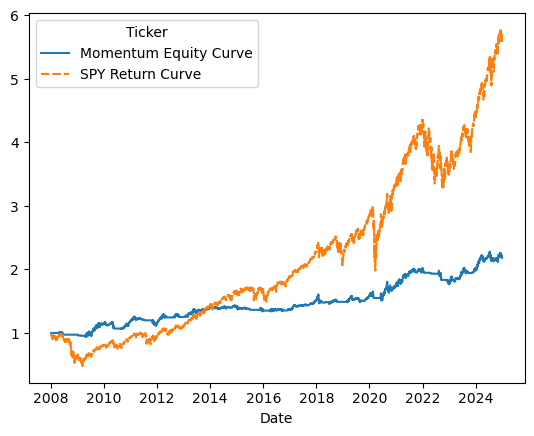

In [965]:
from backtests import momentum_backtest
from features import momentum

df = momentum.calculate_momentum(df)
df = momentum_backtest.generate_signal(df)
df = momentum_backtest.momentum_backtest(df)
sns.lineplot(data = df[['Momentum Equity Curve', 'SPY Return Curve']])

In [966]:
print(f"Momentum-only Sharpe: {metrics.calculate_sharpe(df['Momentum Return'])}")
print(f"Momentum-only max drawdown: {metrics.calculate_max_drawdown(df['Momentum Return'])}")

Momentum-only Sharpe: 0.5970555672248294
Momentum-only max drawdown: -0.12381263268003567


In [967]:
df['Momentum Signal'].describe()

count    4218.000000
mean        0.486866
std         0.388611
min         0.000000
25%         0.000000
50%         0.495821
75%         0.891335
max         1.000000
Name: Momentum Signal, dtype: float64

In [968]:
df['Momentum'].describe()

count    4218.000000
mean        0.025505
std         0.079841
min        -0.527699
25%        -0.001938
50%         0.039666
75%         0.071307
max         0.334965
Name: Momentum, dtype: float64

In [969]:
print(f"SPY Sharpe: {metrics.calculate_sharpe(df['Pct Return'])}")
print(f"SPY max drawdown: {metrics.calculate_max_drawdown(df['Pct Return'])}")

SPY Sharpe: 0.6072656598996097
SPY max drawdown: -0.5148146981514472


<Axes: xlabel='Date'>

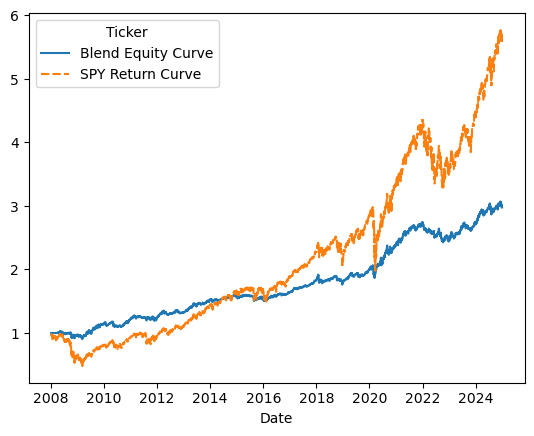

In [970]:
from backtests import blend_signal

df = blend_signal.generate_signal(df)
df = blend_signal.blended_backtest(df)
sns.lineplot(data = df[['Blend Equity Curve', 'SPY Return Curve']])

In [971]:
print(f"Blend Sharpe: {metrics.calculate_sharpe(df['Blend Return'])}")
print(f"Blend max drawdown: {metrics.calculate_max_drawdown(df['Blend Return'])}")

Blend Sharpe: 0.8226611424439607
Blend max drawdown: -0.11560613692408311


In [972]:
print(df['Confidence'].describe())
print(df['State'].value_counts())

count    4278.000000
mean        0.936326
std         0.041540
min         0.649671
25%         0.922697
50%         0.935345
75%         0.950288
max         1.000000
Name: Confidence, dtype: float64
State
0.0_0     2146
1.0_0     1126
0.0_1      861
1.0_1      134
-1.0_0       7
nan_0        4
Name: count, dtype: int64
